In [22]:
import pandas as pd    #loading data
import numpy as np    #mathematical Calculation
import re     #regular exppression for cleaning data
import nltk     #for basics
import matplotlib.pyplot as plt #visualization
from nltk.corpus import stopwords   #to remove be verbs unwanted words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from collections import Counter


#download  required NLTK files
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [23]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

print(df.head())

                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [25]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()
    print('lower case',text)

    text = re.sub(r'[^a-zA-Z\s]','',text)
    print('Special character',text)

    #tokenization
    words = word_tokenize(text)
    print('tokenization',words)

    #remove stopwords
    words = [word for word in  words if word not in stop_words]
    print('stopwords',words)

    #join words again
    cleaned_text = ' '.join(words)
    print('join',cleaned_text)

    return cleaned_text

df['cleaned_review'] = df['Review'].apply(clean_text)

lower case the product quality is excellent and delivery was very fast.
Special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
join product quality excellent delivery fast
lower case very bad packaging and the item was damaged.
Special character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stopwords ['bad', 'packaging', 'item', 'damaged']
join bad packaging item damaged
lower case customer service was helpful and responsive.
Special character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stopwords ['customer', 'service', 'helpful', 'responsive']
join customer service helpful responsive
lower case the delivery was delayed and support team did no

In [18]:
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(review):

    scores = sia.polarity_scores(review)
    compound = scores['compound']

    if compound >= 0.05:
      return 'Positive'

    elif compound <= -0.05:
      return 'Negative'

    else:
      return 'Neutral'
      #Apply Sentiment Analysis

df['sentiment'] = df['cleaned_review'].apply(analyze_sentiment)

print("\n Sentiment Analysis Results")
print(df[['Review','sentiment']])


 Sentiment Analysis Results
                                              Review sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [20]:
all_words = " ".join(df['cleaned_review'])

word_list = all_words.split()

#Count Word Frequency
word_freq = Counter(word_list)

#Display top 10 keywords
print("Top 10 Keywords:")
print(word_freq.most_common(10))

Top 10 Keywords:
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [33]:
negative_reviews = df[df['sentiment']== 'Negative']

negative_words = " ".join(negative_reviews['cleaned_review'])

negative_word_list = negative_words.split()

complaint_freq = Counter(negative_word_list)

print("\n Top 10 common negative keywords")
print(complaint_freq.most_common(10))


 Top 10 common negative keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


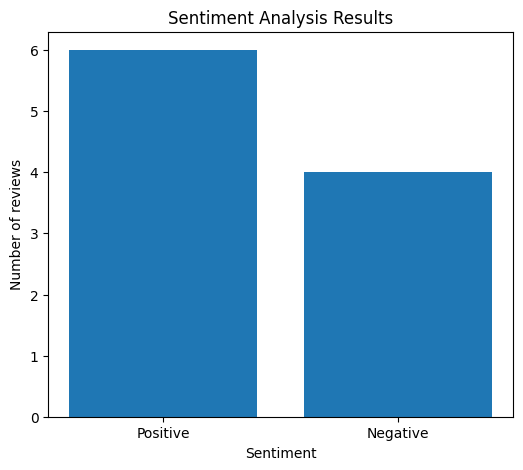

In [36]:
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Number of reviews')
plt.title('Sentiment Analysis Results')
plt.show()


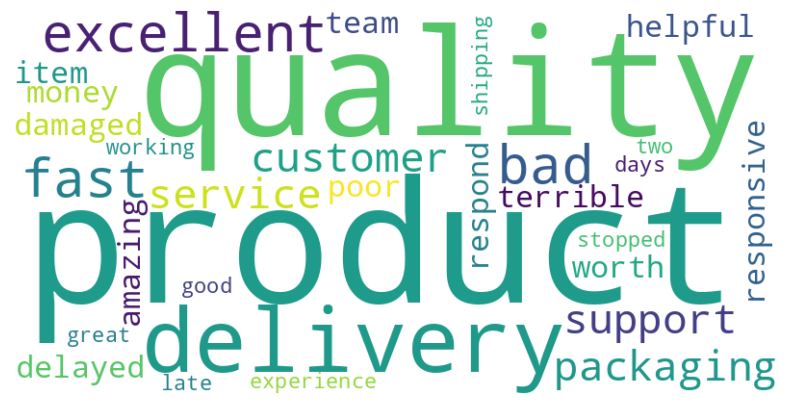

In [38]:
wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color = 'white',
).generate(all_words)

plt.figure(figsize = (10,5))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()
